<a href="https://colab.research.google.com/github/Rabbi1067/Machine-Learning-ML-/blob/main/Multi_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [13]:
df=pd.read_csv('housing_data.csv')

In [14]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.5,1451
1,1,2017,11,2.50,5.5,1455
2,2,2017,10,2.75,5.5,1456
3,3,2017,9,2.00,5.4,1444
4,4,2017,8,2.50,5.4,1437


Drop unneccessary column

In [19]:
df.drop(columns=["Unnamed: 0","year","month"],axis=1, errors='ignore')

,interest_rate,unemployment_rate,index_price
0,2.75,5.5,1451
1,2.50,5.5,1455
2,2.75,5.5,1456
3,2.00,5.4,1444
4,2.50,5.4,1437
...,...,...,...
95,0.25,7.7,920
96,0.25,7.7,904
97,0.50,7.7,900
98,0.25,7.8,907


In [ ]:
df.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True, errors='ignore')

In [20]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.5,1451
1,2.50,5.5,1455
2,2.75,5.5,1456
3,2.00,5.4,1444
4,2.50,5.4,1437


Null value

In [22]:
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


Viualization

In [23]:
import seaborn as sns

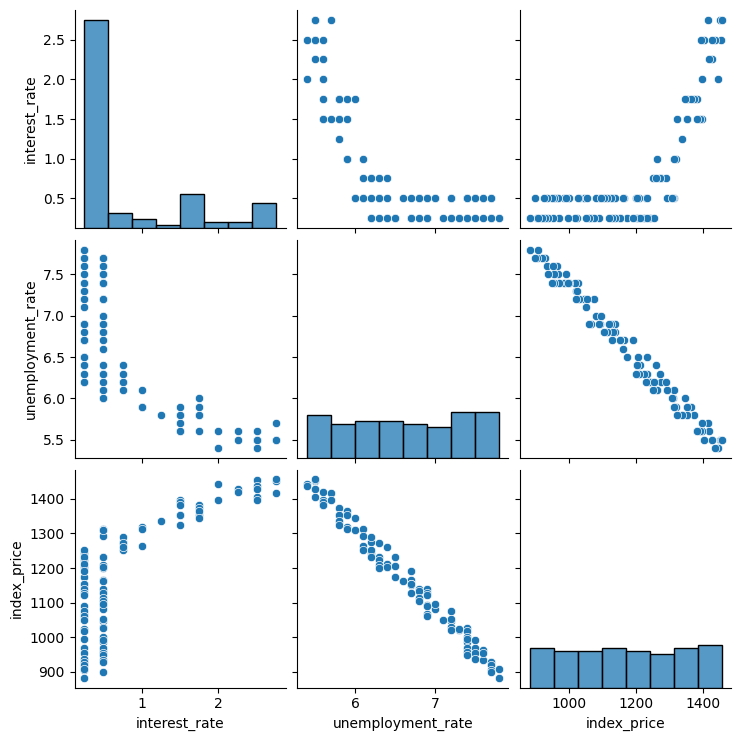

In [24]:
sns.pairplot(df)

In [25]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.760083,0.77419
unemployment_rate,-0.760083,1.000000,-0.99186
index_price,0.774190,-0.991860,1.00000


Visualiza the datapoints more closely

Text(0.5, 1.0, 'Interest Rate')

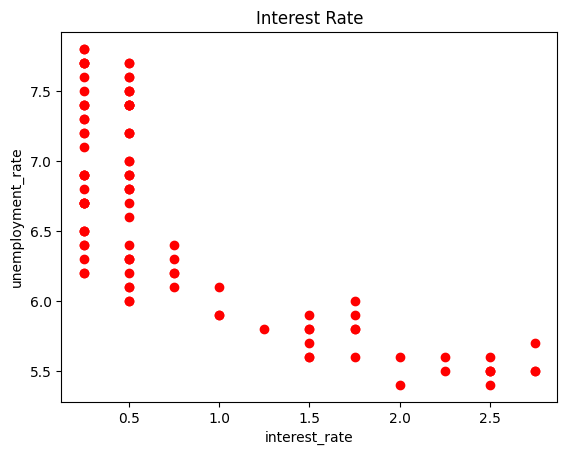

In [28]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='red')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.title('Interest Rate')

Dependent & Dependent Future

In [34]:
x=df.iloc[:,:-1] # Selects all rows and all columns except the last one
y=df.iloc[:,-1] # Selects all rows and the last column

In [35]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.5
1,2.50,5.5
2,2.75,5.5
3,2.00,5.4
4,2.50,5.4


In [36]:
y

,index_price
0,1451
1,1455
2,1456
3,1444
4,1437
...,...
95,920
96,904
97,900
98,907


Train -Test split

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

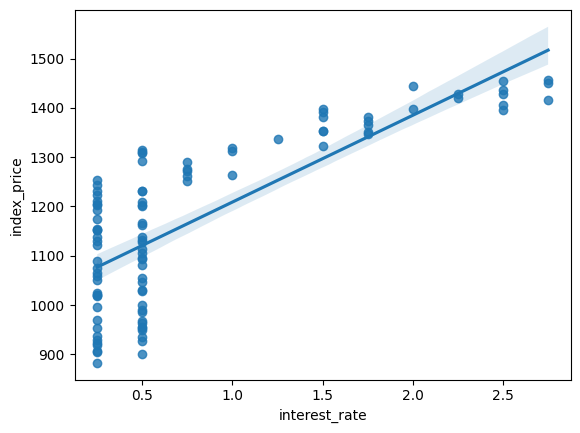

In [48]:
import seaborn as sns
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

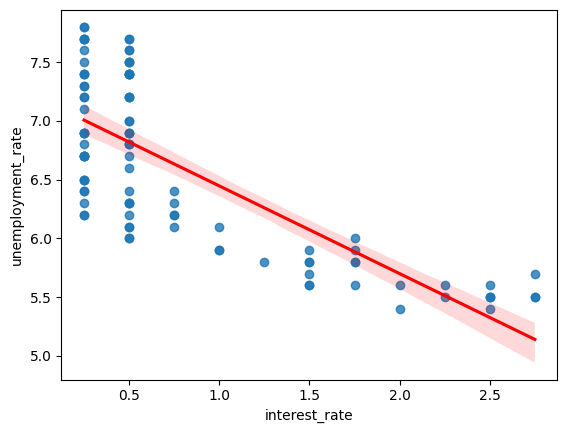

In [50]:
import seaborn as sns
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'], line_kws={'color':'red'})

In [51]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler=StandardScaler()
#scaler.fit(x_train)
X_train=scaler.fit_transform(x_train)
X_test=scaler.fit_transform(x_test)


In [59]:
x_train

,interest_rate,unemployment_rate
55,0.25,6.8
88,0.50,7.4
26,1.00,5.9
42,0.50,6.3
69,0.25,6.9
...,...,...
60,0.50,6.8
71,0.50,7.2
14,1.50,5.6
92,0.25,7.7


In [62]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [63]:
regression.fit(x_train,y_train)

LinearRegression()

In [65]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=10)


In [66]:
validation_score # cv joto dibo joto ta output dibe than average korbe

array([-743.76779471, -300.63656228, -772.88409838, -344.69098254,
       -368.8577874 , -623.06904675, -725.95695436, -245.06729362,
       -505.05073422, -153.72417275])

In [67]:
np.mean(validation_score)

np.float64(-478.3705427016428)

Prediction

In [69]:
y_pred=regression.predict(x_test)

In [70]:
y_pred

array([ 988.63261553, 1143.4149819 , 1035.52403555, 1209.75028177,
       1187.63851515, 1234.52993517, 1314.20466891,  991.3005023 ,
       1410.65539573, 1435.43504913, 1336.31643553, 1259.30958857,
       1035.52403555, 1284.08924196,  944.40908228, 1454.87892898,
        991.3005023 , 1010.74438215, 1377.87208201, 1259.30958857])

*Performance* Metrics

In [71]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,regression.predict(x_test))
mae=mean_absolute_error(y_test,regression.predict(x_test))
emse=np.sqrt(mse)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",emse)

Mean Squared Error:  359.42593084852444
Mean Absolute Error:  16.44410124725482
Root Mean Squared Error:  18.958531874818906


In [76]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression.predict(x_test))
print("R2 score: ",score)

R2 score:  0.9866683890361707


**Adjusted** r^2

In [74]:
#OLS linear regression
import statsmodels.api as sm
x_train_sm=sm.add_constant(x_train)
lr=sm.OLS(y_train,x_train_sm).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            index_price   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     2378.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           6.14e-70
Time:                        09:55:35   Log-Likelihood:                -357.46
No. Observations:                  80   AIC:                             720.9
Df Residuals:                      77   BIC:                             728.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2622.2355     36.097     72.645      0.000    2550.358    2694.113
interest_rate        10.6715      5.122      2.083      0.041       0.472      20.871
unemployment_rate  -221.1177      4.988    -44.331      0.000    -231.050    -211.185
==============================================================================
Omnibus:                        1.538   Durbin-Watson:                   1.803
Prob(Omnibus):                  0.464   Jarque-Bera (JB):                1.506
Skew:                           0.242   Prob(JB):                        0.471
Kurtosis:                       2.533   Cond. No.                         103.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Assumptions

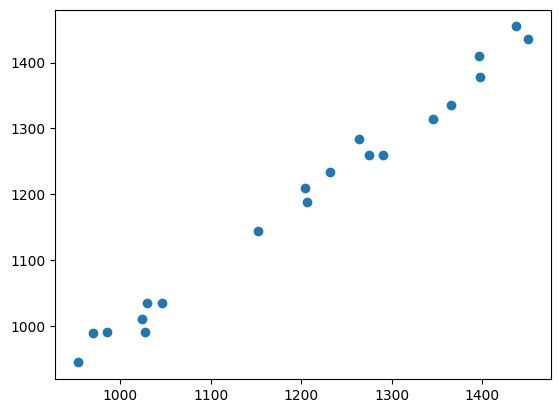

In [77]:
plt.scatter(y_test,y_pred)

In [78]:
residuals=y_test-y_pred
print(residuals)

83   -18.632616
53     8.585018
70    10.475964
45    -5.750282
44    18.361485
39    -2.529935
22    31.795331
80    -5.300502
10   -14.655396
0     15.564951
18    29.683564
30    15.690411
73    -5.524036
33   -20.089242
90     8.590918
4    -17.878929
76    36.699498
77    13.255618
12    19.127918
31    30.690411
Name: index_price, dtype: float64


Plot this residuals

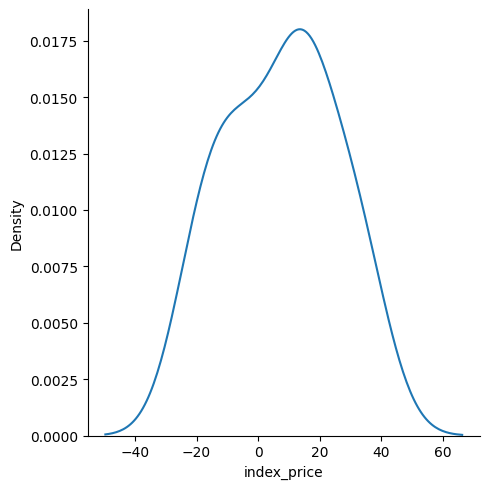

In [81]:
sns.displot(residuals,kind='kde')

Scatter plot with respect to prediction and residuals

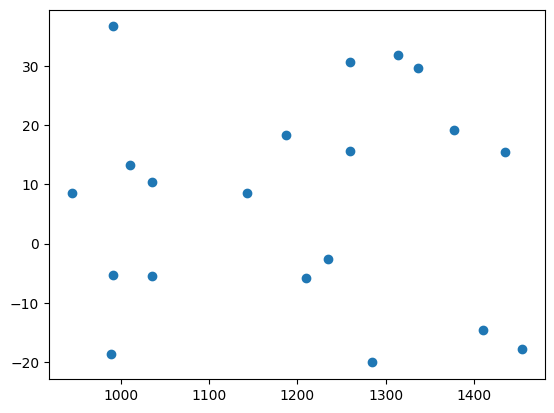

In [84]:
plt.scatter(y_pred,residuals)